# Medicare Part D GLP-1–Based Therapy Utilization and Spending Trends (2014–2024)

**Python/Pandas analysis of national and Georgia CMS prescribing data**

This project evaluates how utilization mix, dosing-frequency mix, gross drug cost, and unit cost changed for selected single-agent GLP-1–based therapies in Medicare Part D from 2014 through 2024. The analysis uses CMS national summary rows as the primary view and Georgia as a focused comparison.

> **Scope note:** Tirzepatide is a dual GIP/GLP-1 receptor agonist. It is included under the broader term *GLP-1–based therapies*. Insulin combination products are excluded.


## Project Overview

### Objective
Translate eleven annual CMS files into a reproducible analysis of utilization and spending trends relevant to pharmacy-benefit and healthcare analytics.

### Key Questions
1. How did national gross drug cost change from 2014 through 2024?
2. How did the utilization and spending mix shift among included therapies?
3. What proportion of standardized 30-day fills came from weekly versus daily therapies?
4. How did gross cost per standardized 30-day fill change nationally and in Georgia?
5. Which therapies contributed most to the change in national gross drug cost in 2024?

### Data Source
[CMS Medicare Part D Prescribers — by Geography and Drug](https://catalog.data.gov/dataset/medicare-part-d-prescribers-by-geography-and-drug-d1df1)

The notebook analyzes the 2014–2024 annual files. Raw CSV files are not stored in this repository because of their size.


## Metric Definitions and Analytical Choices

- **Primary utilization metric — `Tot_30day_Fills`:** Standardized 30-day fills provide a more comparable measure of therapy volume than raw claim counts when days supplied differ.
- **Secondary utilization metric — `Tot_Clms`:** Total prescription claims are retained as an operational-volume measure.
- **Spending metric — `Tot_Drug_Cst`:** Aggregate gross drug cost. This is not rebate-adjusted net PBM cost or plan liability.
- **Beneficiary metric — `Tot_Benes`:** Used only for data-quality review because some values are suppressed. Missing beneficiary values are not imputed as zero.
- **Utilization and spending shares:** Calculated only within the set of included therapies. They should not be interpreted as total U.S. pharmaceutical market share.
- **Geographic comparison:** Uses CMS national summary rows and Georgia state rows. Raw totals are not compared directly across geographies; the comparison focuses on shares and unit-cost metrics.


## 1. Environment Setup

### 1.1 Import Libraries

Pandas and NumPy support data preparation and metric calculations. Matplotlib and Seaborn are used for visualization, while `glob`, `os`, and regular expressions support repeatable loading of annual CSV files.


In [20]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

# File discovery and year extraction
import glob
import os
import re

sns.set_theme(style="whitegrid")


## 2. Data Ingestion and Initial Validation

### 2.1 Load and Combine Annual CMS Files

The loader identifies each annual CSV, extracts the year from the file name, verifies that the required columns exist, and reads only the fields needed for this analysis. Limiting the selected columns reduces memory use while schema validation prevents silent errors when annual files differ.


In [21]:
# Locate annual CMS CSV files.
path = "Raw Data CSV/"
all_files = sorted(
    glob.glob(os.path.join(path, "*.csv")),
    reverse=True,
)

# Retain only fields required for cohort selection and analysis.
columns_to_keep = [
    "Prscrbr_Geo_Lvl",
    "Prscrbr_Geo_Desc",
    "Brnd_Name",
    "Gnrc_Name",
    "Tot_Prscrbrs",
    "Tot_Clms",
    "Tot_30day_Fills",
    "Tot_Drug_Cst",
    "Tot_Benes",
]

df_list = []

print(f"Found {len(all_files)} files. Starting data load...")

for filename in all_files:
    # Extract the two-digit data year from the CMS file name.
    match = re.search(r"DY(\d{2})", os.path.basename(filename))

    if not match:
        print(f"Skipping file because year was not found: {filename}")
        continue

    year = 2000 + int(match.group(1))

    # Confirm that each annual file contains the expected schema.
    available_columns = pd.read_csv(filename, nrows=0).columns
    missing_columns = set(columns_to_keep) - set(available_columns)

    if missing_columns:
        raise ValueError(
            f"{filename} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    temp_df = pd.read_csv(
        filename,
        usecols=columns_to_keep,
        low_memory=False,
    )

    temp_df["Year"] = year
    df_list.append(temp_df)

    print(f"Loaded {year}: {len(temp_df):,} rows")

if not df_list:
    raise ValueError("No valid CSV files were loaded.")

df_all_years = pd.concat(df_list, ignore_index=True)

# Standardize text fields before filtering or comparing values.
text_columns = [
    "Prscrbr_Geo_Lvl",
    "Prscrbr_Geo_Desc",
    "Brnd_Name",
    "Gnrc_Name",
]

for column in text_columns:
    df_all_years[column] = (
        df_all_years[column]
        .astype("string")
        .str.strip()
    )

print(f"\nTotal rows loaded: {len(df_all_years):,}")
print(
    f"Years: {df_all_years['Year'].min()}–"
    f"{df_all_years['Year'].max()}"
)


Found 11 files. Starting data load...
Loaded 2024: 117,661 rows
Loaded 2023: 115,936 rows
Loaded 2022: 115,396 rows
Loaded 2021: 114,891 rows
Loaded 2020: 115,410 rows
Loaded 2019: 114,645 rows
Loaded 2018: 113,607 rows
Loaded 2017: 110,802 rows
Loaded 2016: 109,640 rows
Loaded 2015: 109,032 rows
Loaded 2014: 107,432 rows

Total rows loaded: 1,244,452
Years: 2014–2024


### 2.2 Inspect the Combined Dataset

This diagnostic cell verifies the combined row count, data types, and distributions of the core numeric fields before therapy filtering. It is intended as a reproducibility and quality-control check rather than a substantive analysis.


In [22]:
print(f"Rows: {len(df_all_years):,}")
print(f"Columns: {df_all_years.shape[1]}")

display(
    df_all_years.dtypes
    .rename("Data_Type")
    .to_frame()
)

display(
    df_all_years[
        [
            "Tot_Prscrbrs",
            "Tot_Clms",
            "Tot_30day_Fills",
            "Tot_Drug_Cst",
            "Tot_Benes",
        ]
    ].describe().T
)


Rows: 1,244,452
Columns: 10


,Data_Type
Prscrbr_Geo_Lvl,string[python]
Prscrbr_Geo_Desc,string[python]
Brnd_Name,string[python]
Gnrc_Name,string[python]
Tot_Prscrbrs,int64
Tot_Clms,int64
Tot_30day_Fills,float64
Tot_Drug_Cst,float64
Tot_Benes,float64
Year,int64


,count,mean,std,min,25%,50%,75%,max
Tot_Prscrbrs,1244452.0,1.549772e+03,1.383311e+04,1.0,14.000,63.000,427.000,7.639410e+05
Tot_Clms,1244452.0,2.686000e+04,4.406195e+05,11.0,52.000,282.000,2574.250,7.332621e+07
Tot_30day_Fills,1244452.0,4.481320e+04,8.634986e+05,11.0,66.300,369.900,3510.800,1.803130e+08
Tot_Drug_Cst,1244452.0,3.420333e+06,5.903272e+07,0.0,13569.305,96655.975,650348.475,2.076927e+10
Tot_Benes,1016268.0,9.147638e+03,1.227872e+05,11.0,38.000,167.000,1266.000,1.782480e+07


### 2.3 Review Missing Values

Missingness is reviewed before cohort selection. `Tot_Benes` requires special handling because a blank value may reflect CMS suppression rather than a true zero. The primary claims, standardized-fill, and gross-cost metrics remain available for the main analysis.


In [23]:
# Count missing values in the combined dataset.
missing_values = (
    df_all_years.isna()
    .sum()
    .rename("Missing_Values")
    .to_frame()
)

missing_values["Missing_Pct"] = (
    missing_values["Missing_Values"]
    / len(df_all_years)
    * 100
)

display(missing_values)


,Missing_Values,Missing_Pct
Prscrbr_Geo_Lvl,0,0.000000
Prscrbr_Geo_Desc,29,0.002330
Brnd_Name,0,0.000000
Gnrc_Name,0,0.000000
Tot_Prscrbrs,0,0.000000
Tot_Clms,0,0.000000
Tot_30day_Fills,0,0.000000
Tot_Drug_Cst,0,0.000000
Tot_Benes,228184,18.336103
Year,0,0.000000


## 3. Therapy Cohort Definition and Data Quality

### 3.1 Select Single Agent GLP-1–Based Therapies

An exact generic name whitelist is used instead of a partial string search. This avoids inadvertently including insulin/GLP-1 combination products while retaining historical single-agent therapies that appeared during the study period.


In [24]:
# Exact generic name whitelist for the included single agent therapies.
included_generics = {
    "albiglutide": "Albiglutide",
    "dulaglutide": "Dulaglutide",
    "exenatide": "Exenatide",
    "exenatide microspheres": "Exenatide ER",
    "liraglutide": "Liraglutide",
    "lixisenatide": "Lixisenatide",
    "semaglutide": "Semaglutide",
    "tirzepatide": "Tirzepatide",
}

# Normalize generic names for exact matching.
df_all_years["Gnrc_Name_Key"] = (
    df_all_years["Gnrc_Name"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

glp1_df = df_all_years[
    df_all_years["Gnrc_Name_Key"].isin(included_generics)
].copy()

glp1_df["Therapy"] = (
    glp1_df["Gnrc_Name_Key"]
    .map(included_generics)
)

print("Included generic names:")
print(
    glp1_df[["Gnrc_Name", "Therapy"]]
    .drop_duplicates()
    .sort_values("Therapy")
    .to_string(index=False)
)

# Fail loudly if an insulin combination product remains.
if glp1_df["Gnrc_Name"].str.contains(
    "insulin",
    case=False,
    na=False,
).any():
    raise ValueError(
        "An insulin combination product remains in the analysis."
    )


Included generic names:
             Gnrc_Name      Therapy
           Albiglutide  Albiglutide
           Dulaglutide  Dulaglutide
             Exenatide    Exenatide
Exenatide Microspheres Exenatide ER
           Liraglutide  Liraglutide
          Lixisenatide Lixisenatide
           Semaglutide  Semaglutide
           Tirzepatide  Tirzepatide


### 3.2 Quantify Suppressed Beneficiary Values

`Tot_Benes` is not filled with zero. Instead, the notebook reports how often beneficiary values are missing by year and geographic level. This preserves the distinction between a reported zero and a suppressed or unavailable count.


In [25]:
# Summarize beneficiary-value availability without imputing missing counts.
beneficiary_missing_summary = (
    glp1_df.groupby(["Year", "Prscrbr_Geo_Lvl"])
    .agg(
        Total_Rows=("Tot_Benes", "size"),
        Reported_Beneficiary_Rows=("Tot_Benes", "count"),
        Suppressed_Beneficiary_Rows=(
            "Tot_Benes",
            lambda values: values.isna().sum(),
        ),
    )
    .reset_index()
)

beneficiary_missing_summary["Suppressed_Row_Pct"] = (
    beneficiary_missing_summary["Suppressed_Beneficiary_Rows"]
    / beneficiary_missing_summary["Total_Rows"]
    * 100
)

display(beneficiary_missing_summary)


,Year,Prscrbr_Geo_Lvl,Total_Rows,Reported_Beneficiary_Rows,Suppressed_Beneficiary_Rows,Suppressed_Row_Pct
0,2014,National,7,7,0,0.000000
1,2014,State,294,282,12,4.081633
2,2015,National,8,7,1,12.500000
3,2015,State,369,355,14,3.794038
4,2016,National,7,7,0,0.000000
5,2016,State,374,362,12,3.208556
6,2017,National,10,9,1,10.000000
7,2017,State,375,361,14,3.733333
8,2018,National,10,10,0,0.000000
9,2018,State,487,459,28,5.749487


### 3.3 Validate the Filtered Cohort

The filtered cohort is checked for row count, data types, remaining missingness, and representative records. These checks confirm that the exact-match filter produced the intended therapy set before aggregation.


In [26]:
glp1_df.info()

display(
    glp1_df.isna()
    .sum()
    .rename("Missing_Values")
    .to_frame()
)

display(glp1_df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 4802 entries, 442 to 1242990
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Prscrbr_Geo_Lvl   4802 non-null   string 
 1   Prscrbr_Geo_Desc  4802 non-null   string 
 2   Brnd_Name         4802 non-null   string 
 3   Gnrc_Name         4802 non-null   string 
 4   Tot_Prscrbrs      4802 non-null   int64  
 5   Tot_Clms          4802 non-null   int64  
 6   Tot_30day_Fills   4802 non-null   float64
 7   Tot_Drug_Cst      4802 non-null   float64
 8   Tot_Benes         4587 non-null   float64
 9   Year              4802 non-null   int64  
 10  Gnrc_Name_Key     4802 non-null   string 
 11  Therapy           4802 non-null   object 
dtypes: float64(3), int64(3), object(1), string(5)
memory usage: 487.7+ KB


,Missing_Values
Prscrbr_Geo_Lvl,0
Prscrbr_Geo_Desc,0
Brnd_Name,0
Gnrc_Name,0
Tot_Prscrbrs,0
Tot_Clms,0
Tot_30day_Fills,0
Tot_Drug_Cst,0
Tot_Benes,215
Year,0


,Prscrbr_Geo_Lvl,Prscrbr_Geo_Desc,Brnd_Name,Gnrc_Name,Tot_Prscrbrs,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Benes,Year,Gnrc_Name_Key,Therapy
442,National,National,Bydureon Bcise,Exenatide Microspheres,29951,178845,266630.5,2.152683e+08,38039.0,2024,exenatide microspheres,Exenatide ER
443,National,National,Byetta,Exenatide,3275,11706,19580.0,1.586266e+07,3041.0,2024,exenatide,Exenatide
1802,National,National,Liraglutide,Liraglutide,18209,62242,85916.3,4.808463e+07,24400.0,2024,liraglutide,Liraglutide
2045,National,National,Mounjaro,Tirzepatide,194653,5103556,6093348.5,6.334739e+09,894243.0,2024,tirzepatide,Tirzepatide
2353,National,National,Ozempic,Semaglutide,286517,10413554,14353450.6,1.296581e+10,1951892.0,2024,semaglutide,Semaglutide


## 4. Geographic Scope

### 4.1 Create National and Georgia Cohorts

CMS national summary rows are used directly for the national analysis rather than summing state rows. Georgia is retained as a focused state-level comparison. Combining the two labeled cohorts supports consistent downstream calculations.


In [27]:
# Select CMS national summary rows.
national_df = glp1_df[
    glp1_df["Prscrbr_Geo_Lvl"].eq("National")
].copy()
national_df["Geography"] = "National"

# Select Georgia state rows.
georgia_df = glp1_df[
    glp1_df["Prscrbr_Geo_Lvl"].eq("State")
    & glp1_df["Prscrbr_Geo_Desc"].eq("Georgia")
].copy()
georgia_df["Geography"] = "Georgia"

analysis_df = pd.concat(
    [national_df, georgia_df],
    ignore_index=True,
)

# Confirm therapy-row availability by geography and year.
display(
    analysis_df.groupby(["Geography", "Year"])
    .size()
    .unstack(fill_value=0)
)


Year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Geography,,,,,,,,,,,
Georgia,6,7,7,7,9,10,9,8,9,8,10
National,7,8,7,10,10,11,10,10,10,11,11


## 5. Metric Engineering

### 5.1 Aggregate Additive Metrics and Calculate Unit Costs

Claims, standardized 30-day fills, and gross drug cost can be summed across brand-level rows. Beneficiary and prescriber counts are not aggregated across therapies because the same person may appear in more than one drug row. Unit-cost measures separate changes in volume from changes in cost per standardized unit.


In [28]:
# Metrics that can be added safely across included brand-level rows.
additive_metrics = [
    "Tot_Clms",
    "Tot_30day_Fills",
    "Tot_Drug_Cst",
]

therapy_trends = (
    analysis_df.groupby(
        ["Geography", "Year", "Therapy"],
        as_index=False,
    )[additive_metrics]
    .sum()
    .sort_values(["Geography", "Therapy", "Year"])
)

# Calculate gross cost per operational and standardized utilization unit.
therapy_trends["Cost_Per_Claim"] = (
    therapy_trends["Tot_Drug_Cst"]
    / therapy_trends["Tot_Clms"].where(
        therapy_trends["Tot_Clms"] > 0
    )
)

therapy_trends["Cost_Per_30Day_Fill"] = (
    therapy_trends["Tot_Drug_Cst"]
    / therapy_trends["Tot_30day_Fills"].where(
        therapy_trends["Tot_30day_Fills"] > 0
    )
)


### 5.2 Calculate Within-Class Utilization and Spending Shares

For each geography and year, the notebook calculates each therapy's share of total claims, standardized 30-day fills, and gross drug cost among the included therapies. These are **within class composition measures**, not total market shares.


In [29]:
share_metrics = {
    "Tot_Clms": "Claim_Share_Pct",
    "Tot_30day_Fills": "Fill_Share_Pct",
    "Tot_Drug_Cst": "Spending_Share_Pct",
}

for metric, output_column in share_metrics.items():
    yearly_total = therapy_trends.groupby(
        ["Geography", "Year"]
    )[metric].transform("sum")

    therapy_trends[output_column] = np.where(
        yearly_total > 0,
        therapy_trends[metric] / yearly_total * 100,
        np.nan,
    )


### 5.3 Map Standard Dosing Frequency

Brand names are mapped to their standard daily or weekly dosing schedule. An explicit unmapped-brand check prevents unreviewed products from being silently dropped from the frequency analysis.


In [30]:
brand_frequency_map = {
    # Exenatide
    "Byetta": "Daily",
    "Bydureon": "Weekly",
    "Bydureon Pen": "Weekly",
    "Bydureon Bcise": "Weekly",

    # Albiglutide
    "Tanzeum": "Weekly",

    # Dulaglutide
    "Trulicity": "Weekly",

    # Liraglutide
    "Liraglutide": "Daily",  # Generic/unbranded product label in 2024 CMS data.
    "Victoza 2-Pak": "Daily",
    "Victoza 3-Pak": "Daily",
    "Saxenda": "Daily",

    # Lixisenatide
    "Adlyxin": "Daily",

    # Semaglutide
    "Ozempic": "Weekly",
    "Wegovy": "Weekly",
    "Rybelsus": "Daily",

    # Tirzepatide
    "Mounjaro": "Weekly",
    "Zepbound": "Weekly",
}

analysis_df["Dosage_Frequency"] = (
    analysis_df["Brnd_Name"]
    .map(brand_frequency_map)
)

unmapped_brands = sorted(
    analysis_df.loc[
        analysis_df["Dosage_Frequency"].isna(),
        "Brnd_Name",
    ]
    .dropna()
    .unique()
)

if unmapped_brands:
    print("Review these unmapped brands:")
    for brand in unmapped_brands:
        print(f" - {brand}")
else:
    print("All included brands were assigned a dosing frequency.")


All included brands were assigned a dosing frequency.


### 5.4 Aggregate Daily and Weekly Utilization

The frequency-level table sums claims, standardized fills, and gross cost by geography and year. Weekly share is calculated using standardized 30-day fills so that the comparison reflects normalized therapy volume rather than raw prescription event counts.


In [31]:
frequency_trends = (
    analysis_df.dropna(subset=["Dosage_Frequency"])
    .groupby(
        ["Geography", "Year", "Dosage_Frequency"],
        as_index=False,
    )[["Tot_Clms", "Tot_30day_Fills", "Tot_Drug_Cst"]]
    .sum()
)

frequency_total_fills = frequency_trends.groupby(
    ["Geography", "Year"]
)["Tot_30day_Fills"].transform("sum")

frequency_trends["Frequency_Fill_Share_Pct"] = (
    frequency_trends["Tot_30day_Fills"]
    / frequency_total_fills
    * 100
)


## 6. Results

### 6.1 National Utilization Mix by Therapy

The stacked area chart shows how each therapy's share of national standardized 30-day fills changed over time. It highlights product-mix shifts within the included therapy set rather than overall pharmaceutical market share.


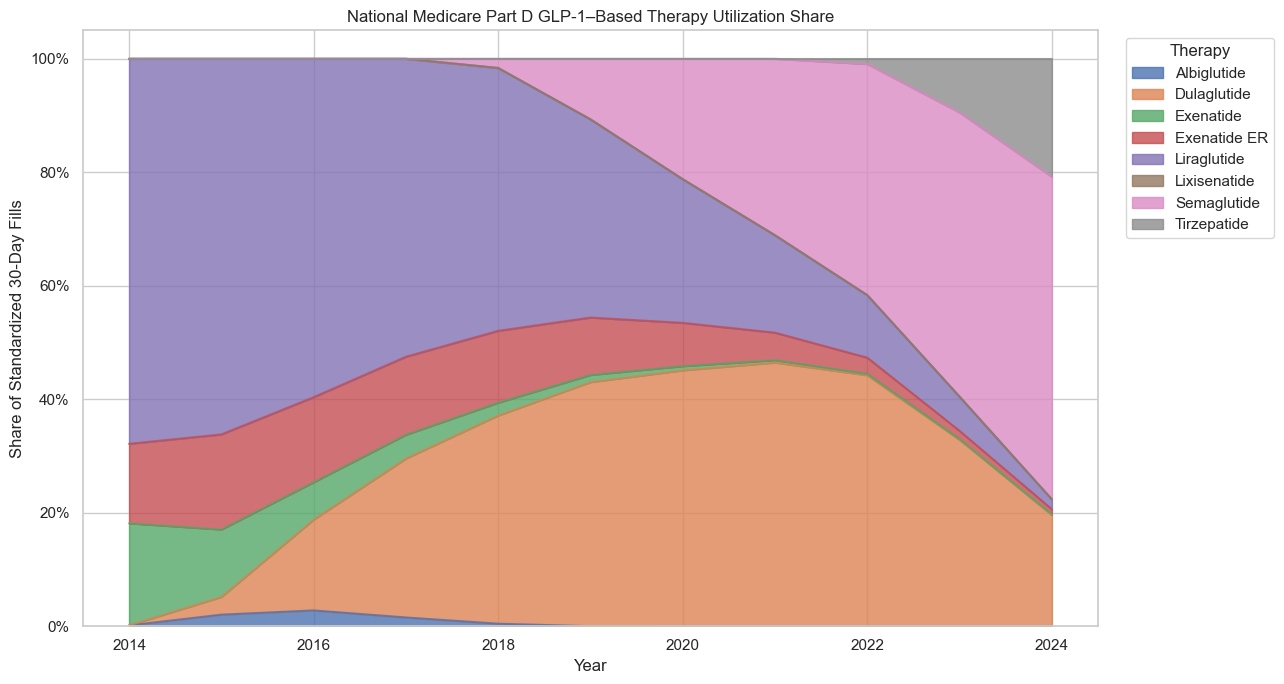

In [32]:
national_trends = therapy_trends[
    therapy_trends["Geography"].eq("National")
].copy()

national_fill_share = national_trends.pivot(
    index="Year",
    columns="Therapy",
    values="Fill_Share_Pct",
).fillna(0)

ax = national_fill_share.plot(
    kind="area",
    stacked=True,
    figsize=(13, 7),
    alpha=0.8,
)

ax.set_title(
    "National Medicare Part D GLP-1–Based Therapy Utilization Share"
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Standardized 30-Day Fills")
ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)
ax.legend(
    title="Therapy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


### 6.2 National Aggregate Gross Drug Cost

This trend summarizes the total reported gross drug cost for the included therapies in national Medicare Part D data. The measure captures aggregate spending growth but should not be interpreted as rebate-adjusted net cost.


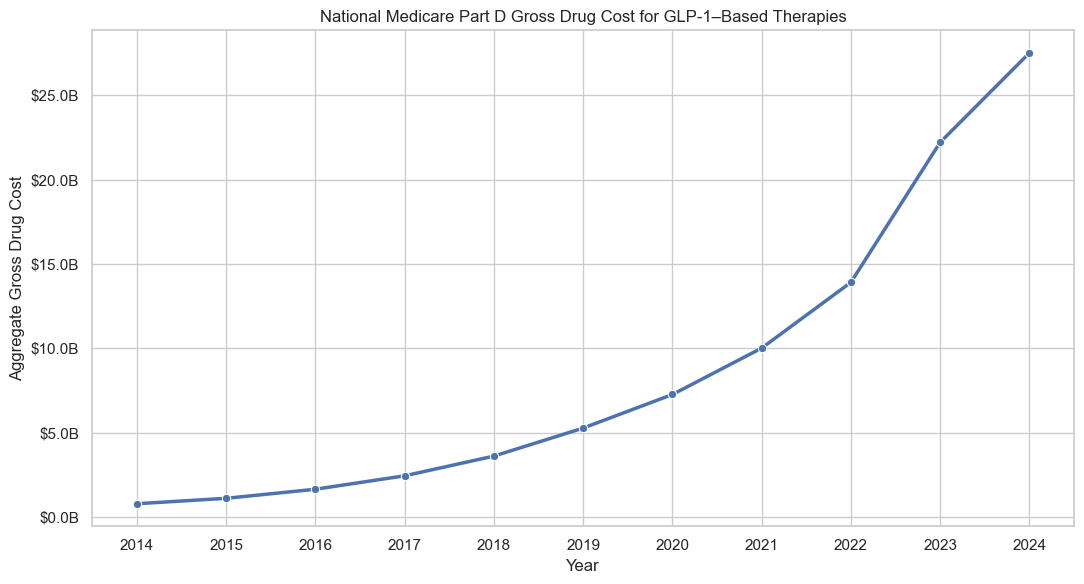

In [33]:
annual_summary = (
    therapy_trends.groupby(
        ["Geography", "Year"],
        as_index=False,
    )[["Tot_Clms", "Tot_30day_Fills", "Tot_Drug_Cst"]]
    .sum()
)

annual_summary["Cost_Per_Claim"] = (
    annual_summary["Tot_Drug_Cst"]
    / annual_summary["Tot_Clms"]
)

annual_summary["Cost_Per_30Day_Fill"] = (
    annual_summary["Tot_Drug_Cst"]
    / annual_summary["Tot_30day_Fills"]
)

national_annual = annual_summary[
    annual_summary["Geography"].eq("National")
].copy()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=national_annual,
    x="Year",
    y="Tot_Drug_Cst",
    marker="o",
    linewidth=2.5,
)

plt.title(
    "National Medicare Part D Gross Drug Cost "
    "for GLP-1–Based Therapies"
)
plt.xlabel("Year")
plt.ylabel("Aggregate Gross Drug Cost")
plt.xticks(national_annual["Year"])

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"${value / 1e9:.1f}B"
    )
)

plt.tight_layout()
plt.show()


### 6.3 National Spending Mix by Therapy

This chart attributes each year's included-therapy gross drug cost across the individual therapies. Comparing it with the utilization-share chart helps distinguish changes in product mix from changes in unit cost.


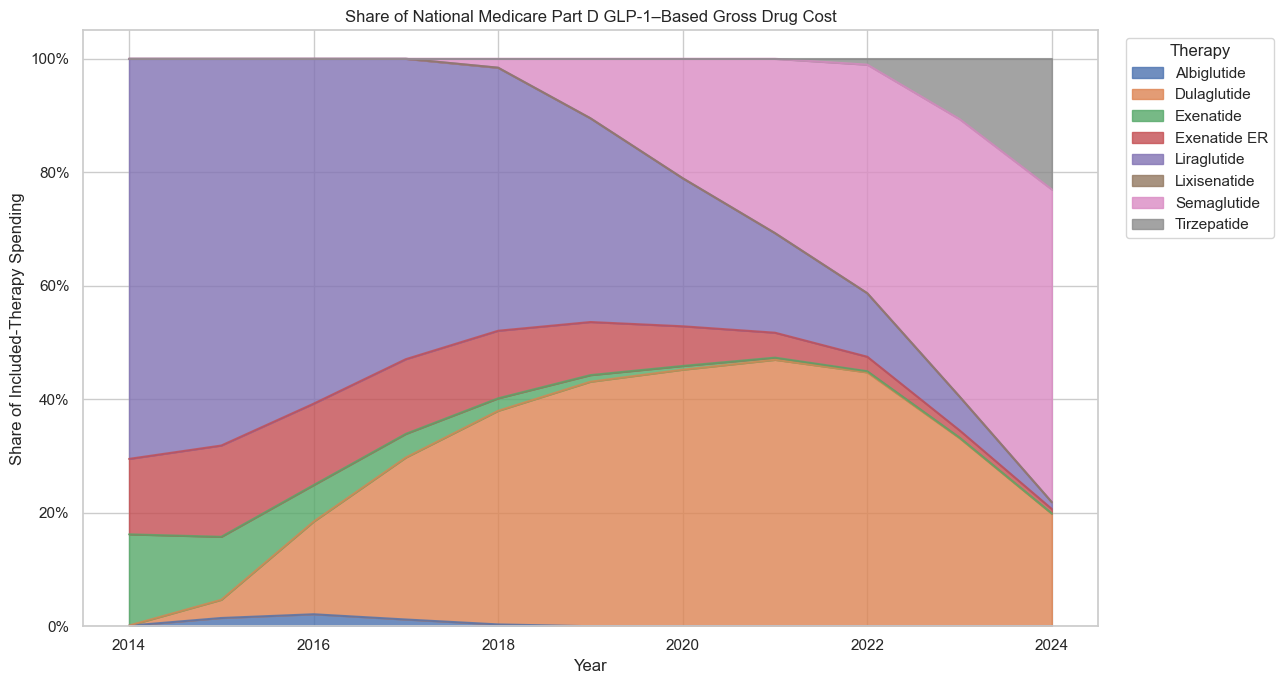

In [34]:
national_cost_share = national_trends.pivot(
    index="Year",
    columns="Therapy",
    values="Spending_Share_Pct",
).fillna(0)

ax = national_cost_share.plot(
    kind="area",
    stacked=True,
    figsize=(13, 7),
    alpha=0.8,
)

ax.set_title(
    "Share of National Medicare Part D "
    "GLP-1–Based Gross Drug Cost"
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Included-Therapy Spending")
ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)
ax.legend(
    title="Therapy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


### 6.4 Weekly Therapy Share: Georgia vs National

The comparison tracks the percentage of standardized 30-day fills attributable to weekly products. Similar direction across Georgia and the national data suggests that the shift toward weekly therapies was not limited to one geography; it does not establish patient preference or causation.


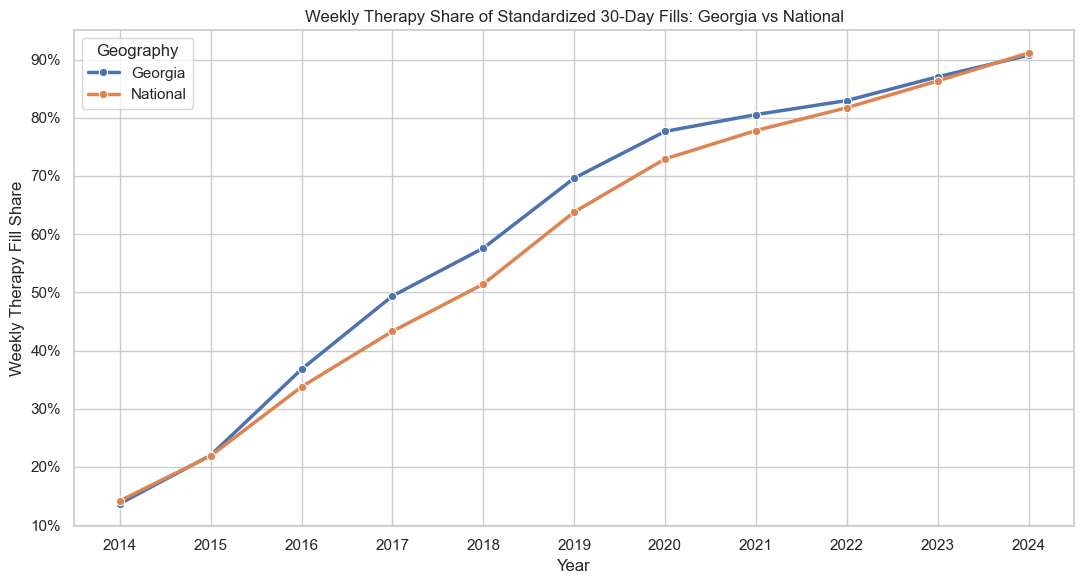

In [35]:
weekly_share = frequency_trends[
    frequency_trends["Dosage_Frequency"].eq("Weekly")
].copy()

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=weekly_share,
    x="Year",
    y="Frequency_Fill_Share_Pct",
    hue="Geography",
    marker="o",
    linewidth=2.5,
)

plt.title(
    "Weekly Therapy Share of Standardized 30-Day Fills: "
    "Georgia vs National"
)
plt.xlabel("Year")
plt.ylabel("Weekly Therapy Fill Share")
plt.xticks(
    sorted(weekly_share["Year"].unique())
)
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.tight_layout()
plt.show()


### 6.5 Gross Cost per Standardized 30-Day Fill

This unit-cost comparison normalizes gross drug cost by standardized 30-day fills. It provides a more informative Georgia-versus-national comparison than raw total cost, because the two populations differ substantially in size.


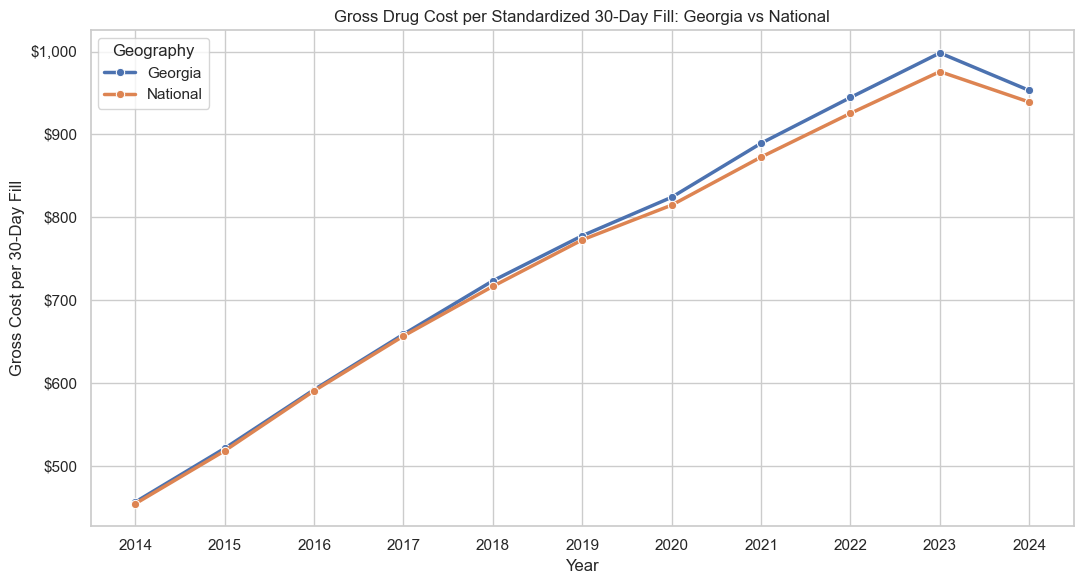

In [36]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=annual_summary,
    x="Year",
    y="Cost_Per_30Day_Fill",
    hue="Geography",
    marker="o",
    linewidth=2.5,
)

plt.title(
    "Gross Drug Cost per Standardized 30-Day Fill: "
    "Georgia vs National"
)
plt.xlabel("Year")
plt.ylabel("Gross Cost per 30-Day Fill")
plt.xticks(
    sorted(annual_summary["Year"].unique())
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"${value:,.0f}"
    )
)

plt.tight_layout()
plt.show()


### 6.6 Latest-Year National Cost Drivers

Year-over-year changes are calculated by therapy to identify which products contributed most to the latest annual change in gross drug cost. Absolute dollar change is the primary driver measure; percentage growth for recently launched products should be interpreted cautiously because of small prior-year bases. The code automatically uses the most recent year loaded, which is 2024 when the full 2014–2024 file set is present.


In [37]:
national_drivers = (
    national_trends
    .sort_values(["Therapy", "Year"])
    .copy()
)

national_drivers["YoY_Cost_Change"] = (
    national_drivers.groupby("Therapy")["Tot_Drug_Cst"]
    .diff()
)

national_drivers["YoY_Cost_Growth_Pct"] = (
    national_drivers.groupby("Therapy")["Tot_Drug_Cst"]
    .pct_change(fill_method=None)
    * 100
)

national_drivers["YoY_Fill_Growth_Pct"] = (
    national_drivers.groupby("Therapy")["Tot_30day_Fills"]
    .pct_change(fill_method=None)
    * 100
)

national_drivers["YoY_Unit_Cost_Growth_Pct"] = (
    national_drivers.groupby("Therapy")[
        "Cost_Per_30Day_Fill"
    ]
    .pct_change(fill_method=None)
    * 100
)

latest_year = national_drivers["Year"].max()

latest_cost_drivers = (
    national_drivers[
        national_drivers["Year"].eq(latest_year)
    ][
        [
            "Therapy",
            "Tot_30day_Fills",
            "Tot_Drug_Cst",
            "Cost_Per_30Day_Fill",
            "YoY_Cost_Change",
            "YoY_Cost_Growth_Pct",
            "YoY_Fill_Growth_Pct",
            "YoY_Unit_Cost_Growth_Pct",
        ]
    ]
    .sort_values(
        "YoY_Cost_Change",
        ascending=False,
    )
)

print(f"National cost drivers for {latest_year}:")

display(
    latest_cost_drivers.style.format(
        {
            "Tot_30day_Fills": "{:,.0f}",
            "Tot_Drug_Cst": "${:,.0f}",
            "Cost_Per_30Day_Fill": "${:,.2f}",
            "YoY_Cost_Change": "${:,.0f}",
            "YoY_Cost_Growth_Pct": "{:,.1f}%",
            "YoY_Fill_Growth_Pct": "{:,.1f}%",
            "YoY_Unit_Cost_Growth_Pct": "{:,.1f}%",
        },
        na_rep="N/A",
    )
)


National cost drivers for 2024:


,Therapy,Tot_30day_Fills,Tot_Drug_Cst,Cost_Per_30Day_Fill,YoY_Cost_Change,YoY_Cost_Growth_Pct,YoY_Fill_Growth_Pct,YoY_Unit_Cost_Growth_Pct
123,Semaglutide,"16,642,657","$15,156,231,415",$910.69,"$4,299,745,108",39.6%,46.1%,-4.4%
124,Tirzepatide,"6,093,729","$6,335,126,528","$1,039.61","$3,974,480,287",168.4%,183.0%,-5.2%
120,Exenatide,"19,580","$15,862,662",$810.15,"$-4,775,877",-23.1%,-21.2%,-2.5%
121,Exenatide ER,"266,630","$215,268,334",$807.37,"$-68,665,989",-24.2%,-20.1%,-5.1%
122,Liraglutide,"515,408","$328,893,714",$638.12,"$-992,551,842",-75.1%,-62.4%,-33.8%
119,Dulaglutide,"5,748,807","$5,452,031,864",$948.38,"$-1,908,885,665",-25.9%,-23.1%,-3.7%


## 7. Clinical and Market Context

The decline in liraglutide's within-class utilization share after the introduction of semaglutide should be interpreted as **product substitution within a rapidly expanding therapeutic class**, not as proof of a single causal mechanism. Several clinically plausible factors align with the observed shift:

- **Dosing frequency:** Injectable semaglutide products are administered once weekly, whereas liraglutide products are administered once daily. Lower administration frequency may reduce treatment burden, but this aggregated dataset does not measure convenience, persistence, or patient preference.
- **Comparative weight-loss efficacy:** In the randomized STEP 8 trial, once weekly semaglutide 2.4 mg produced substantially greater mean weight loss than once daily liraglutide 3.0 mg at 68 weeks. This provides a clinically credible explanation for some of the shift toward semaglutide, although the CMS data cannot directly link trial evidence to individual prescribing decisions.  
  [STEP 8 randomized clinical trial](https://doi.org/10.1001/jama.2021.23619)
- **Oral treatment availability:** Rybelsus provided an oral semaglutide option during the study period. This may have broadened use among patients and prescribers seeking a non-injectable GLP-1 therapy, but the dataset does not measure injection aversion or route preference.
- **Expanding clinical indications:** In March 2024, the FDA approved Wegovy injection to reduce the risk of cardiovascular death, myocardial infarction, and stroke in adults with cardiovascular disease and overweight or obesity. This label expansion may have influenced late-2024 utilization, but annual aggregated data cannot isolate its effect from other clinical, formulary, supply, and market factors.  
  [FDA cardiovascular-risk indication announcement](https://www.fda.gov/news-events/press-announcements/fda-approves-first-treatment-reduce-risk-serious-heart-problems-specifically-adults-obesity-or)

These factors should therefore be presented as **evidence-informed clinical context**, not as causal findings produced by the Medicare Part D dataset.


In [ ]:
from IPython.display import Markdown, display

# Build a conclusion that updates automatically when a newer annual file is added.
first_year = int(national_annual["Year"].min())
latest_year = int(national_annual["Year"].max())

first_annual = (
    national_annual.loc[national_annual["Year"].eq(first_year)]
    .iloc[0]
)
latest_annual = (
    national_annual.loc[national_annual["Year"].eq(latest_year)]
    .iloc[0]
)

national_weekly = (
    weekly_share.loc[weekly_share["Geography"].eq("National")]
    .sort_values("Year")
)
georgia_weekly = (
    weekly_share.loc[weekly_share["Geography"].eq("Georgia")]
    .sort_values("Year")
)

first_weekly_share = float(
    national_weekly.loc[
        national_weekly["Year"].eq(first_year),
        "Frequency_Fill_Share_Pct",
    ].iloc[0]
)
latest_weekly_share = float(
    national_weekly.loc[
        national_weekly["Year"].eq(latest_year),
        "Frequency_Fill_Share_Pct",
    ].iloc[0]
)
latest_georgia_weekly_share = float(
    georgia_weekly.loc[
        georgia_weekly["Year"].eq(latest_year),
        "Frequency_Fill_Share_Pct",
    ].iloc[0]
)

latest_therapy_rows = (
    national_trends.loc[national_trends["Year"].eq(latest_year)]
    .copy()
)
fill_leader = (
    latest_therapy_rows
    .sort_values("Tot_30day_Fills", ascending=False)
    .iloc[0]
)
spending_leader = (
    latest_therapy_rows
    .sort_values("Tot_Drug_Cst", ascending=False)
    .iloc[0]
)

latest_driver_rows = (
    latest_cost_drivers
    .dropna(subset=["YoY_Cost_Change"])
    .sort_values("YoY_Cost_Change", ascending=False)
)

top_driver_rows = (
    latest_driver_rows.loc[
        latest_driver_rows["YoY_Cost_Change"] > 0
    ]
    .nlargest(3, "YoY_Cost_Change")
)

top_driver_names = top_driver_rows["Therapy"].tolist()

top_driver_text = ", ".join(top_driver_names)

liraglutide_rows = (
    national_trends.loc[
        national_trends["Therapy"].eq("Liraglutide")
    ]
    .sort_values("Year")
)
if not liraglutide_rows.empty:
    liraglutide_peak = liraglutide_rows.loc[
        liraglutide_rows["Fill_Share_Pct"].idxmax()
    ]
    liraglutide_latest = liraglutide_rows.loc[
        liraglutide_rows["Year"].eq(latest_year)
    ]
    if liraglutide_latest.empty:
        liraglutide_latest_share = 0.0
    else:
        liraglutide_latest_share = float(
            liraglutide_latest["Fill_Share_Pct"].iloc[0]
        )
    liraglutide_sentence = (
        f"Liraglutide's standardized-fill share peaked at "
        f"{liraglutide_peak['Fill_Share_Pct']:.1f}% in "
        f"{int(liraglutide_peak['Year'])} and declined to "
        f"{liraglutide_latest_share:.1f}% by {latest_year}."
    )
else:
    liraglutide_sentence = (
        "Liraglutide was not present in the final national trend table."
    )

latest_yoy_cost_change = (
    float(latest_annual["Tot_Drug_Cst"])
    - float(
        national_annual.loc[
            national_annual["Year"].eq(latest_year - 1),
            "Tot_Drug_Cst",
        ].iloc[0]
    )
)
latest_yoy_cost_growth = (
    latest_yoy_cost_change
    / float(
        national_annual.loc[
            national_annual["Year"].eq(latest_year - 1),
            "Tot_Drug_Cst",
        ].iloc[0]
    )
    * 100
)

conclusion_text = f"""
## 8. Conclusion

The analysis shows a substantial change in both the composition and reported gross cost of GLP-1–based therapies in Medicare Part D from {first_year} through {latest_year}.

1. **Gross drug cost increased sharply.** National aggregate gross drug cost for the included therapies rose from **${first_annual['Tot_Drug_Cst'] / 1e9:,.1f} billion** in {first_year} to **${latest_annual['Tot_Drug_Cst'] / 1e9:,.1f} billion** in {latest_year}. The latest annual increase was approximately **${latest_yoy_cost_change / 1e9:,.1f} billion ({latest_yoy_cost_growth:,.1f}%)**.

2. **The therapy mix shifted toward newer products.** In {latest_year}, **{fill_leader['Therapy']}** represented the largest share of standardized 30-day fills, while **{spending_leader['Therapy']}** represented the largest share of included-therapy gross drug cost. {liraglutide_sentence}

3. **Weekly therapies became the dominant dosing-frequency group.** Weekly products increased from **{first_weekly_share:,.1f}%** of national standardized 30-day fills in {first_year} to **{latest_weekly_share:,.1f}%** in {latest_year}. Georgia followed the same overall direction and reached **{latest_georgia_weekly_share:,.1f}%** in the latest year.

4. **Unit cost also increased.** National gross cost per standardized 30-day fill rose from **${first_annual['Cost_Per_30Day_Fill']:,.0f}** in {first_year} to **${latest_annual['Cost_Per_30Day_Fill']:,.0f}** in {latest_year}. This indicates that total spending growth reflected both higher therapy volume and changes in the cost and product mix of each standardized fill.

5. **Recent spending growth remained concentrated.** The largest absolute contributors to the {latest_year} year-over-year gross-cost change were **{top_driver_text}**. Absolute dollar changes are more informative than percentage growth for recently launched products with small prior-year bases.

Overall, the results document a continuing shift toward newer, predominantly weekly GLP-1–based therapies and a large increase in reported Medicare Part D gross drug cost through {latest_year}. The analysis is descriptive: it identifies utilization, spending, and product-mix changes but does not establish that dosing frequency, comparative efficacy, formulary decisions, supply conditions, marketing, or patient preference caused those changes.
"""

display(Markdown(conclusion_text))



## 8. Conclusion

The analysis shows a substantial change in both the composition and reported gross cost of GLP-1–based therapies in Medicare Part D from 2014 through 2024.

1. **Gross drug cost increased sharply.** National aggregate gross drug cost for the included therapies rose from **$0.8 billion** in 2014 to **$27.5 billion** in 2024. The latest annual increase was approximately **$5.3 billion (23.9%)**.

2. **The therapy mix shifted toward newer products.** In 2024, **Semaglutide** represented the largest share of standardized 30-day fills, while **Semaglutide** represented the largest share of included-therapy gross drug cost. Liraglutide's standardized-fill share peaked at 67.9% in 2014 and declined to 1.8% by 2024.

3. **Weekly therapies became the dominant dosing-frequency group.** Weekly products increased from **14.2%** of national standardized 30-day fills in 2014 to **91.1%** in 2024. Georgia followed the same overall direction and reached **90.7%** in the latest year.

4. **Unit cost also increased.** National gross cost per standardized 30-day fill rose from **$454** in 2014 to **$939** in 2024. This indicates that total spending growth reflected both higher therapy volume and changes in the cost and product mix of each standardized fill.

5. **Recent spending growth remained concentrated.** The largest absolute contributors to the 2024 year-over-year gross-cost change were **Semaglutide, Tirzepatide**. Absolute dollar changes are more informative than percentage growth for recently launched products with small prior-year bases.

Overall, the results document a continuing shift toward newer, predominantly weekly GLP-1–based therapies and a large increase in reported Medicare Part D gross drug cost through 2024. The analysis is descriptive: it identifies utilization, spending, and product-mix changes but does not establish that dosing frequency, comparative efficacy, formulary decisions, supply conditions, marketing, or patient preference caused those changes.


## 9. Limitations

1. **Aggregated data:** The source is summarized by geography and drug rather than patient. It cannot measure individual switching, persistence, adherence, clinical outcomes, comorbidities, or specific indications such as diabetes, obesity, cardiovascular-risk reduction, obstructive sleep apnea, or MASH.

2. **Beneficiary suppression:** Some `Tot_Benes` values are missing because of reporting rules. These values were not imputed, and beneficiary counts were excluded from the primary utilization and share calculations.

3. **Utilization proxy:** Standardized 30-day fills improve comparability across prescriptions with different days supplied, but they are not equivalent to unique patients, medication possession ratio, proportion of days covered, or confirmed medication use.

4. **Gross rather than net cost:** `Tot_Drug_Cst` represents reported aggregate gross drug cost. The data do not provide rebate-adjusted net cost, manufacturer discounts, formulary terms, plan liability, or the separate financial contributions of plans and beneficiaries.

5. **Nominal-dollar comparison:** Costs were not adjusted for inflation. Part of the increase in cost per standardized fill may reflect general price-level changes over the eleven-year period.

6. **Within-class shares:** Utilization and spending shares use only the included single-agent GLP-1–based therapies as the denominator. They are not estimates of total U.S. drug-market share, total anti-obesity-drug share, or total antidiabetic-drug share.

7. **Geographic comparison:** Georgia and national comparisons are not adjusted for Medicare enrollment, demographic composition, disease prevalence, or local benefit design. Raw volume differences should therefore not be interpreted as comparative utilization rates.

8. **Dosing-frequency interpretation:** Frequency was mapped from standard product dosing. The observed relationship between weekly-product share and utilization is descriptive and does not prove that dosing convenience caused adoption.

9. **Launch and base effects:** Very large percentage growth rates for newly introduced therapies may result from small prior-year values. Absolute dollar and fill changes are more stable measures of contribution.

10. **Clinical and market attribution:** The dataset cannot separate the effects of comparative efficacy, route of administration, label expansions, guideline changes, formulary placement, rebates, shortages, promotion, or patient and prescriber preferences. These factors are discussed only as clinically plausible context.

11. **Temporal coverage and publication lag:** The analysis ends in calendar year 2024 and therefore does not capture post 2024 clinical guideline and labeling changes or newer market and policy developments. In particular, it does not reflect the U.S. launch of Wegovy tablets in January 2026, the FDA approval of oral orforglipron (Foundayo) in April 2026, or the Medicare GLP-1 Bridge that began July 1, 2026. The Bridge operates outside the standard Part D benefit payment flow, so its utilization and payments may not appear in this specific Part D dataset in the same manner as ordinary Part D claims.

12. **2024 annual aggregation:** Events introduced during 2024, including the cardiovascular-risk indication for Wegovy, may affect only part of the calendar year. Annual totals cannot identify the timing or independent effect of such changes.


## 10. Reproducibility

1. Download the 2014–2024 annual CMS *Medicare Part D Prescribers — by Geography and Drug* CSV files.
2. Place them in a folder named `Raw Data CSV` at the project root.
3. Run the notebook from top to bottom.
4. Confirm that the loader reports 11 annual files and a 2014–2024 year range.
5. Review the schema, therapy whitelist, unmapped-brand check, and suppression summary before interpreting the charts.